In [2]:
# Jupyter Notebook - 代码

# 导入必要的库
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import tensorflow_model_optimization as tfmot  # 新增剪枝库

# 设定日志级别
tf.get_logger().setLevel('ERROR')


# 🔹 超参数
IMG_SIZE = (128, 128)
AUTOTUNE = tf.data.AUTOTUNE

In [3]:
# -------------------------------- 第一阶段训练 ---------------------------------
# 🔹 数据集路径
base_dir = './dataset'
train_dir = os.path.join(base_dir, 'Origin')
valid_dir = os.path.join(base_dir, 'Origin')

BATCH_SIZE = 128
# 🔹 加载数据集
train_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=12,
    batch_size=BATCH_SIZE, image_size=IMG_SIZE)

validation_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir, validation_split=0.2, subset="validation", seed=12,
    batch_size=BATCH_SIZE, image_size=IMG_SIZE)

class_names = train_dataset_raw.class_names
print("Class Names:", class_names)

# 预处理函数
def preprocess_image(image, label):
    return image, label

# 加载数据集
train_dataset = (train_dataset_raw
                 .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                 .cache()
                 .shuffle(1000)
                 .prefetch(AUTOTUNE))

validation_dataset = (validation_dataset_raw
                      .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                      .cache()
                      .prefetch(AUTOTUNE))


Found 3053 files belonging to 15 classes.
Using 2443 files for training.
Found 3053 files belonging to 15 classes.
Using 610 files for validation.
Class Names: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o']


In [5]:
# 🔹 构建模型
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNet(
    input_shape=IMG_SHAPE, include_top=False, alpha=0.25, weights='imagenet')

# 冻结除最后4层外的所有层
base_model.trainable = True
# for layer in base_model.layers[:-0]:
#     layer.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])
model.build((None, 128, 128, 3))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 128, 128, 3)       0         
                                                                 
 mobilenet_0.25_128 (Functio  (None, 4, 4, 256)        218544    
 nal)                                                            
                                                                 
 global_average_pooling2d_1   (None, 256)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 15)                3855      
                                                                 
Total params: 222,399
Trainable params: 216,927
Non-tr

In [6]:
# 编译模型
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001, decay_steps=10000, decay_rate=0.90, staircase=True)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# 训练第一阶段
early_stopping = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)


In [7]:
history = model.fit(train_dataset, validation_data=validation_dataset,
                    epochs=100, callbacks=[early_stopping])

# 保存第一阶段模型
model.save('./model/stage1_model.h5')

Epoch 1/100
20/20 [==============================] - 10s 133ms/step - loss: 4.4772 - accuracy: 0.1077 - val_loss: 3.5374 - val_accuracy: 0.1279
Epoch 2/100
20/20 [==============================] - 1s 42ms/step - loss: 3.4105 - accuracy: 0.1887 - val_loss: 3.0006 - val_accuracy: 0.2295
Epoch 3/100
20/20 [==============================] - 1s 42ms/step - loss: 2.7018 - accuracy: 0.2804 - val_loss: 2.5542 - val_accuracy: 0.3213
Epoch 4/100
20/20 [==============================] - 1s 41ms/step - loss: 2.1019 - accuracy: 0.3885 - val_loss: 2.2515 - val_accuracy: 0.4082
Epoch 5/100
20/20 [==============================] - 1s 41ms/step - loss: 1.8507 - accuracy: 0.4417 - val_loss: 1.9086 - val_accuracy: 0.4705
Epoch 6/100
20/20 [==============================] - 1s 42ms/step - loss: 1.5589 - accuracy: 0.5305 - val_loss: 1.6362 - val_accuracy: 0.5197
Epoch 7/100
20/20 [==============================] - 1s 42ms/step - loss: 1.3615 - accuracy: 0.5772 - val_loss: 1.4257 - val_accuracy: 0.5672
Epoc

第二阶段

In [9]:
# 🔹 数据集路径
base_dir = './dataset'
train_dir = os.path.join(base_dir, 'YASUO_80')
valid_dir = os.path.join(base_dir, 'YASUO_80')

BATCH_SIZE = 64

# 加载数据集
train_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=21,
    batch_size=BATCH_SIZE, image_size=IMG_SIZE)

validation_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir, validation_split=0.2, subset="validation", seed=21,
    batch_size=BATCH_SIZE, image_size=IMG_SIZE)

# 数据预处理（同第一阶段）
train_dataset = (train_dataset_raw
                 .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                 .cache()
                 .shuffle(1000)
                 .prefetch(AUTOTUNE))

validation_dataset = (validation_dataset_raw
                      .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                      .cache()
                      .prefetch(AUTOTUNE))

# 加载第一阶段模型
model = tf.keras.models.load_model('./model/stage1_model.h5')

Found 3053 files belonging to 15 classes.
Using 2443 files for training.
Found 3053 files belonging to 15 classes.
Using 610 files for validation.


In [11]:
history = model.fit(train_dataset, validation_data=validation_dataset,
                    epochs=100, callbacks=[early_stopping])

# 保存第一阶段模型
model.save('./model/stage2_model.h5')

Epoch 1/100


39/39 [==============================] - 1s 24ms/step - loss: 0.0374 - accuracy: 0.9910 - val_loss: 0.0984 - val_accuracy: 0.9689
Epoch 2/100
39/39 [==============================] - 1s 23ms/step - loss: 0.0356 - accuracy: 0.9922 - val_loss: 0.0932 - val_accuracy: 0.9672
Epoch 3/100
39/39 [==============================] - 1s 22ms/step - loss: 0.0268 - accuracy: 0.9955 - val_loss: 0.0990 - val_accuracy: 0.9656
Epoch 4/100
39/39 [==============================] - 1s 22ms/step - loss: 0.0263 - accuracy: 0.9951 - val_loss: 0.0974 - val_accuracy: 0.9656
Epoch 5/100
39/39 [==============================] - 1s 22ms/step - loss: 0.0244 - accuracy: 0.9955 - val_loss: 0.0989 - val_accuracy: 0.9656
Epoch 6/100
39/39 [==============================] - 1s 22ms/step - loss: 0.0286 - accuracy: 0.9930 - val_loss: 0.1016 - val_accuracy: 0.9639
Epoch 7/100
39/39 [==============================] - 1s 22ms/step - loss: 0.0259 - accuracy: 0.9947 - val_loss: 0.1030 - val_accuracy: 0.9623


第三阶段

In [13]:
# 🔹 剪枝参数配置
PRUNING_PARAMS = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.30,
        final_sparsity=0.60,
        begin_step=0,
        end_step=2000,
        frequency=100
    )
}

# 加载第二阶段模型
model = tf.keras.models.load_model('./model/stage2_model.h5')

# 🔹 分离 Rescaling 层和基础模型
rescale_layer = model.layers[0]  # 提取 Rescaling 层
prunable_model = tf.keras.Sequential(model.layers[1:])  # 排除 Rescaling 后的模型

# 🔹 应用剪枝到可剪枝部分
with tfmot.sparsity.keras.prune_scope():  # 确保剪枝作用域正确
    pruned_model = tfmot.sparsity.keras.prune_low_magnitude(
        prunable_model, **PRUNING_PARAMS
    )

# 🔹 重新组合模型
final_model = tf.keras.Sequential([
    rescale_layer,  # 前置 Rescaling
    pruned_model    # 剪枝后的模型部分
])

# 编译模型
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [14]:
# 🔹 数据增强
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.125),
    tf.keras.layers.RandomZoom(0.5),
    tf.keras.layers.RandomTranslation(height_factor=0.25, width_factor=0.25),
    tf.keras.layers.RandomBrightness(0.25),
    tf.keras.layers.RandomContrast(0.5)
])

# 预处理函数（添加增强）
def preprocess_image_aug(image, label):
    image = data_augmentation(image)
    return image, label

In [18]:
# 加载数据集（使用新数据集）
base_dir = './dataset'
train_dir = os.path.join(base_dir, 'YASUO_80')
valid_dir = os.path.join(base_dir, 'YASUO_80')

BATCH_SIZE = 32
train_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=21,
    batch_size=BATCH_SIZE, image_size=IMG_SIZE)

validation_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir, validation_split=0.2, subset="validation", seed=21,
    batch_size=BATCH_SIZE, image_size=IMG_SIZE)

# 数据预处理（应用增强）
train_dataset = (train_dataset_raw
                 .map(preprocess_image_aug, num_parallel_calls=AUTOTUNE)
                 .cache()
                 .shuffle(1000)
                 .prefetch(AUTOTUNE))

validation_dataset = (validation_dataset_raw
                      .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                      .cache()
                      .prefetch(AUTOTUNE))

Found 3053 files belonging to 15 classes.
Using 2443 files for training.
Found 3053 files belonging to 15 classes.
Using 610 files for validation.


In [19]:
# 🔹 添加剪枝回调
pruning_callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),
    tfmot.sparsity.keras.PruningSummaries(log_dir='./logs_pruning')
]

In [20]:
# 训练第三阶段
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=100,
    callbacks=[early_stopping, pruning_callbacks]
)


Epoch 1/100
77/77 [==============================] - 2s 19ms/step - loss: 0.0485 - accuracy: 0.9836 - val_loss: 0.0266 - val_accuracy: 0.9951
Epoch 2/100
77/77 [==============================] - 1s 15ms/step - loss: 0.0314 - accuracy: 0.9910 - val_loss: 0.0284 - val_accuracy: 0.9951
Epoch 3/100
77/77 [==============================] - 1s 15ms/step - loss: 0.0284 - accuracy: 0.9930 - val_loss: 0.0347 - val_accuracy: 0.9885
Epoch 4/100
77/77 [==============================] - 1s 15ms/step - loss: 0.0210 - accuracy: 0.9963 - val_loss: 0.0331 - val_accuracy: 0.9902
Epoch 5/100
77/77 [==============================] - 1s 15ms/step - loss: 0.0222 - accuracy: 0.9943 - val_loss: 0.0297 - val_accuracy: 0.9967
Epoch 6/100
77/77 [==============================] - 1s 15ms/step - loss: 0.0172 - accuracy: 0.9963 - val_loss: 0.0313 - val_accuracy: 0.9951


In [24]:
# # 保存剪枝后的模型
# pruned_model_path = './model/stage3_pruned_model.h5'
# tf.keras.models.save_model(model, pruned_model_path, include_optimizer=True)

# 去除剪枝包装
final_model = tfmot.sparsity.keras.strip_pruning(model)
final_model.save('./model/stage3_pruned_final.h5')

In [25]:
# 加载剪枝后的模型
model = tf.keras.models.load_model('./model/stage3_pruned_final.h5')

def representative_dataset():
    for image_batch, _ in tqdm(train_dataset.take(500), desc="Processing"):
        yield [tf.cast(image_batch, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8
tflite_model_quant = converter.convert()

with open('./model/stage3_pruned_quant.tflite', 'wb') as f:
    f.write(tflite_model_quant)

d:\miniconda\envs\tf\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "
Processing: 100%|██████████| 77/77 [00:13<00:00,  5.82it/s]


20/20 [==============================] - 0s 18ms/step


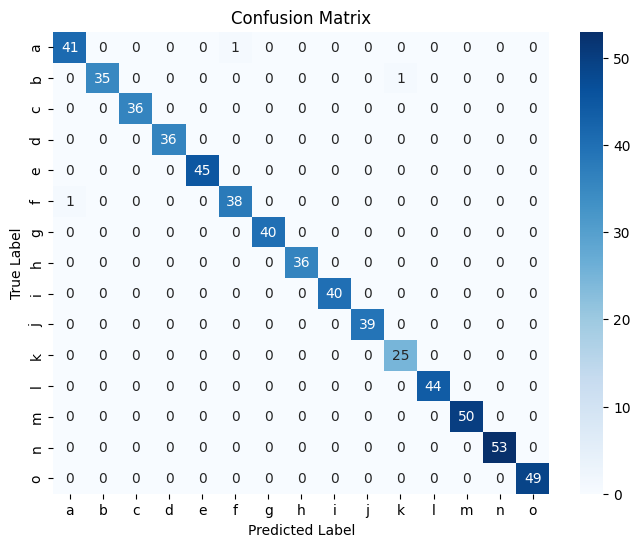

In [27]:
# 混淆矩阵
y_pred = np.argmax(model.predict(validation_dataset), axis=1)
y_true = np.concatenate([labels.numpy() for _, labels in validation_dataset])

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()